# Predictive Maintenance Classifier

## Objective
Predict whether an industrial machine will fail based on sensor readings.

## Dataset
AI4I 2020 Predictive Maintenance — UCI ML Repository | 10,000 rows | Binary classification

## Tools
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, XGBoost

## Phase 1 — Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("ai4i2020.csv")

In [3]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
print(df['Machine failure'].value_counts()) 

Machine failure
0    9661
1     339
Name: count, dtype: int64


## Phase 2 — Exploratory Data Analysis (EDA)

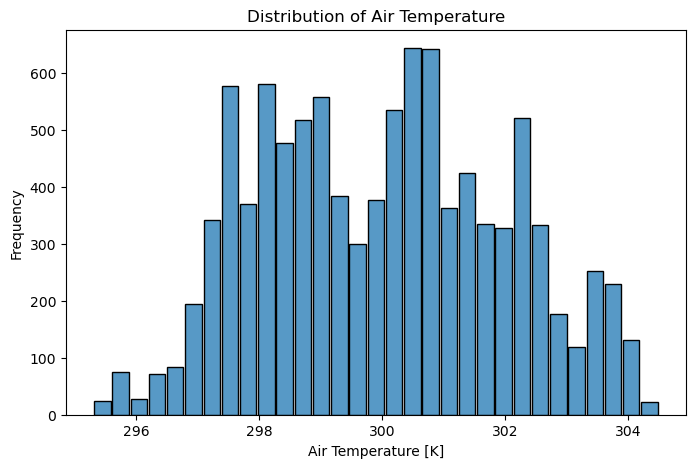

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df['Air temperature [K]'], shrink=0.9)

plt.xlabel('Air Temperature [K]')
plt.ylabel('Frequency')
plt.title('Distribution of Air Temperature') #Air temperature = surrounding environment temperature

plt.show()

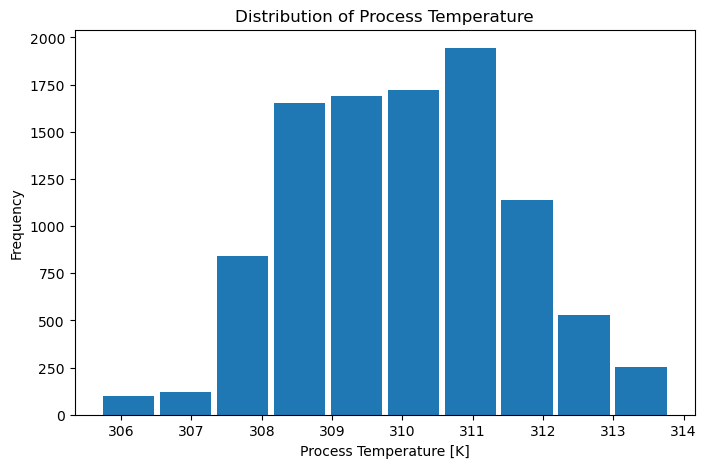

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df['Process temperature [K]'], rwidth=0.9)

plt.xlabel('Process Temperature [K]')
plt.ylabel('Frequency')
plt.title('Distribution of Process Temperature') # Process temperature = machine operating temperature during work

plt.show()

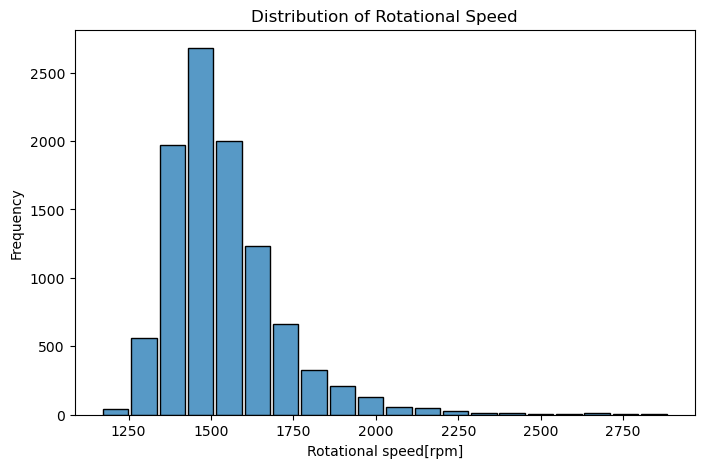

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Rotational speed [rpm]'], bins=20, shrink = 0.9)

plt.xlabel('Rotational speed[rpm]')
plt.ylabel('Frequency')
plt.title('Distribution of Rotational Speed')

plt.show()

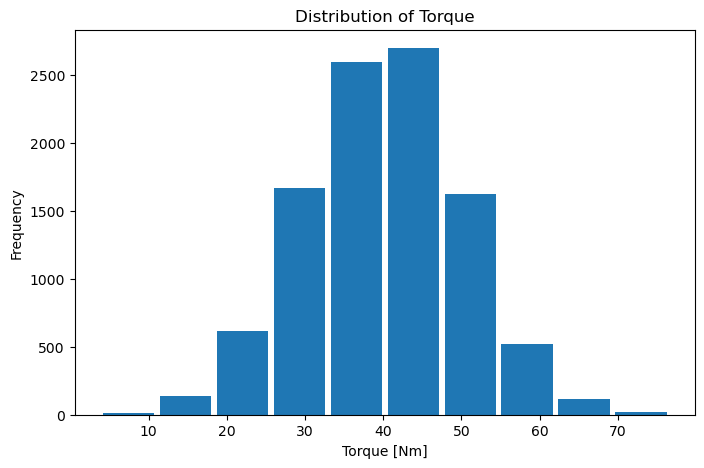

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df['Torque [Nm]'], rwidth=0.9)

plt.xlabel('Torque [Nm]')  #Nm= newton meters
plt.ylabel('Frequency')
plt.title('Distribution of Torque')

plt.show()

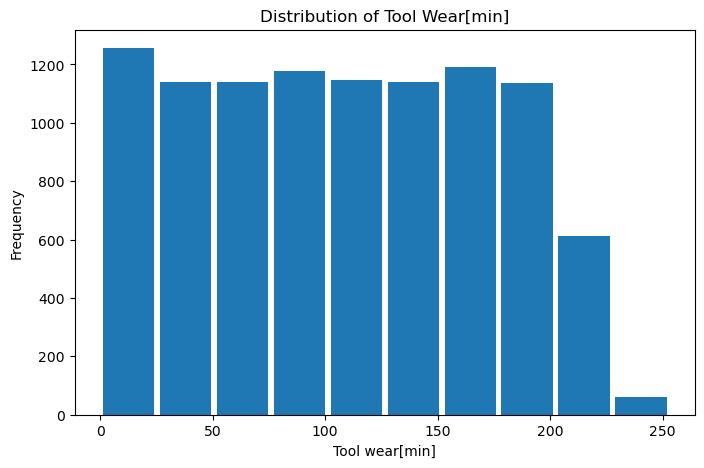

In [11]:
plt.figure(figsize=[8,5])

plt.hist(df['Tool wear [min]'], rwidth = 0.9)

plt.xlabel('Tool wear[min]')
plt.ylabel('Frequency')
plt.title("Distribution of Tool Wear[min]")

plt.show()

In [12]:
corr = df.corr(numeric_only=True) 

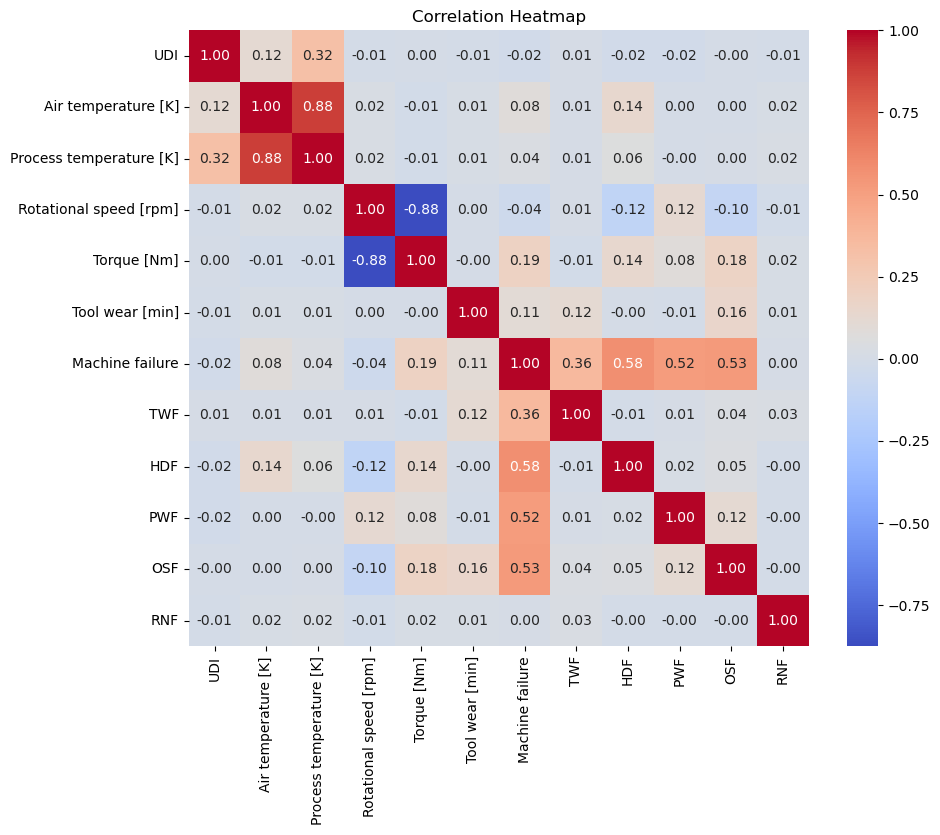

In [13]:
plt.figure(figsize=(10,8))

sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [14]:
key_features = ['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Machine failure']

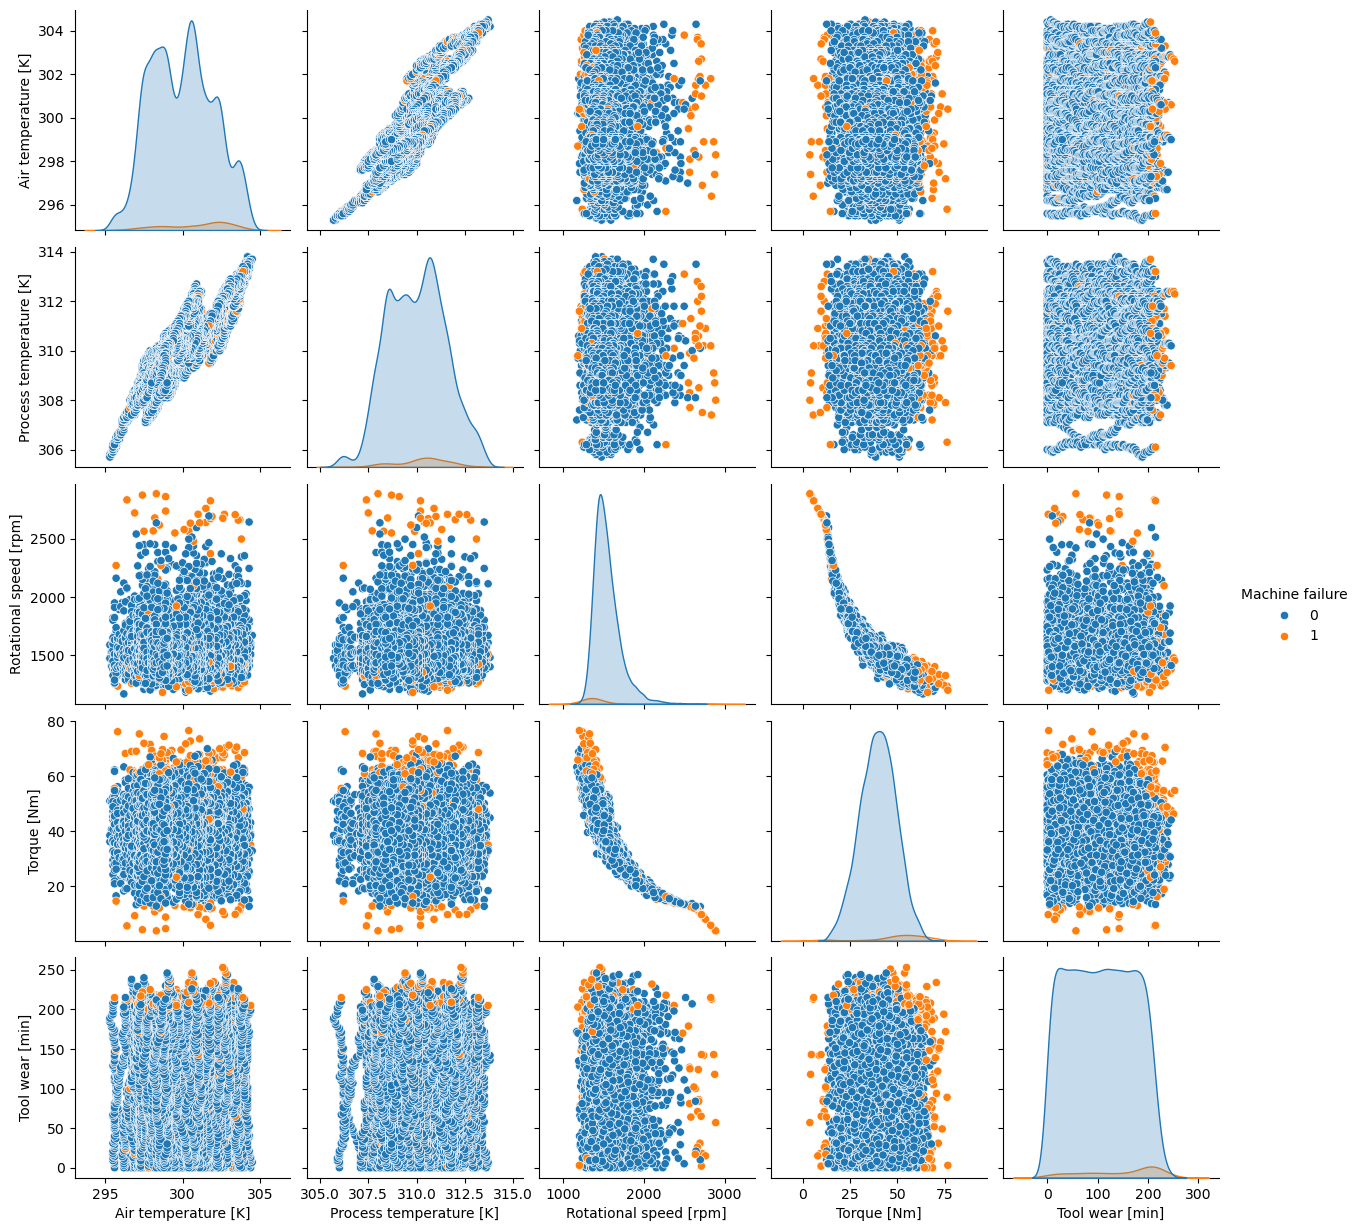

In [15]:
sns.pairplot(df[key_features], hue='Machine failure')
plt.show()

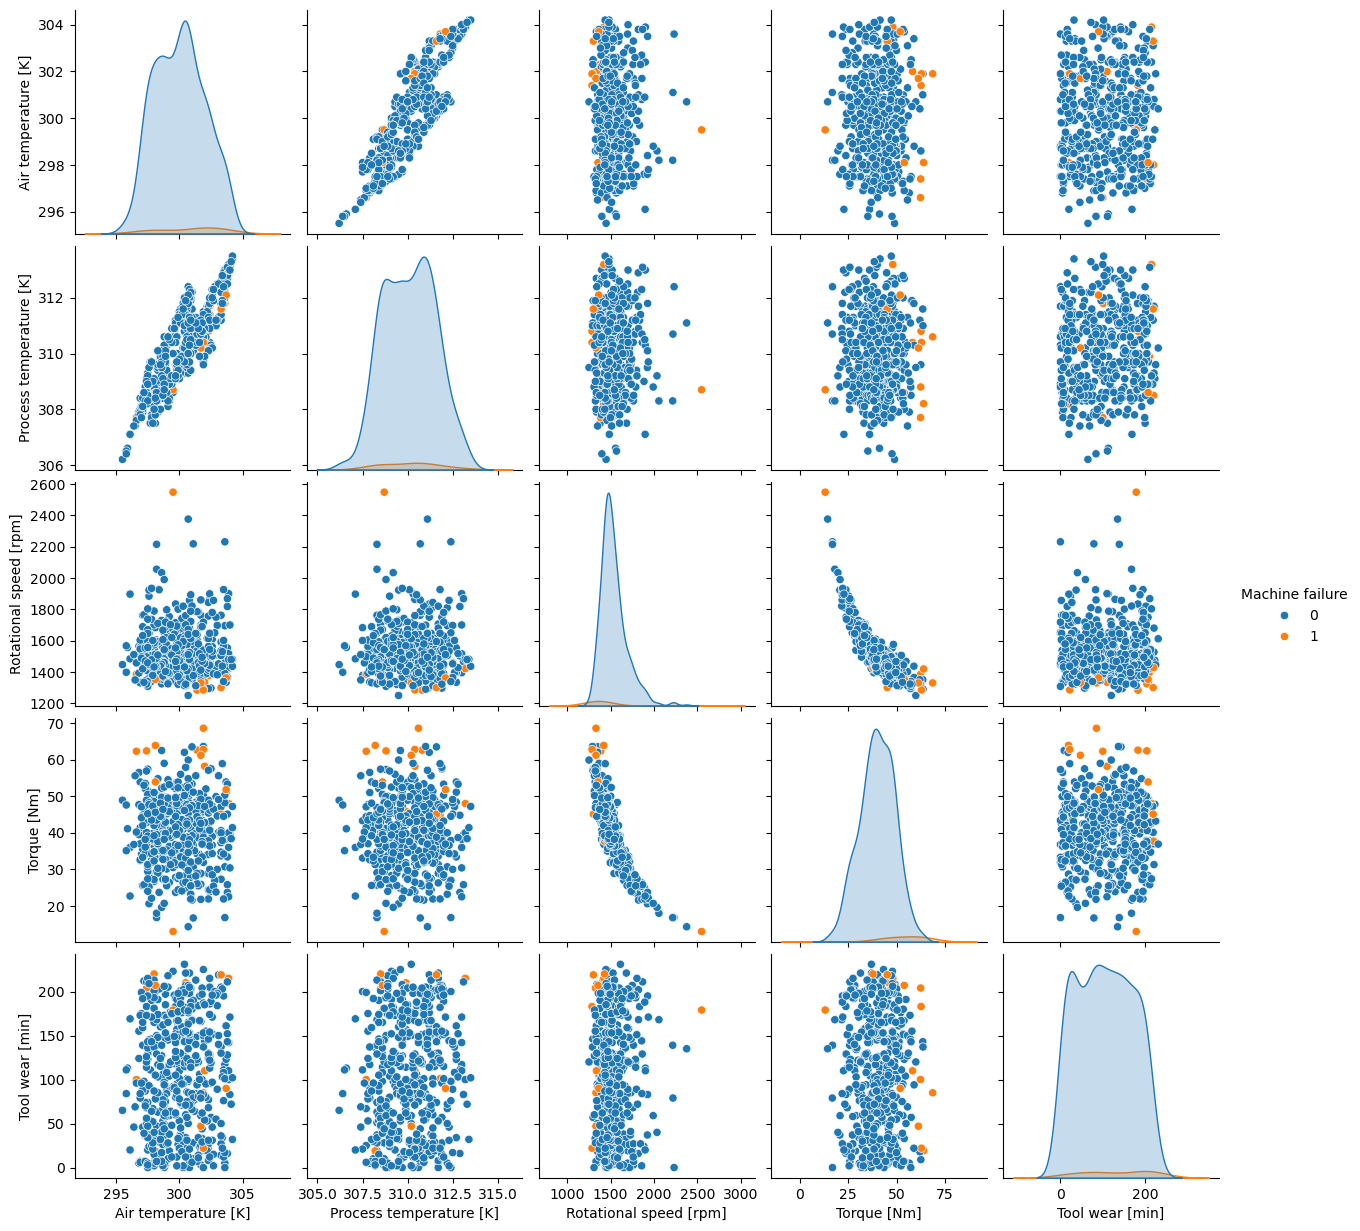

In [16]:
sample_df = df[key_features].sample(500, random_state=42)

sns.pairplot(sample_df, hue='Machine failure')

plt.show()

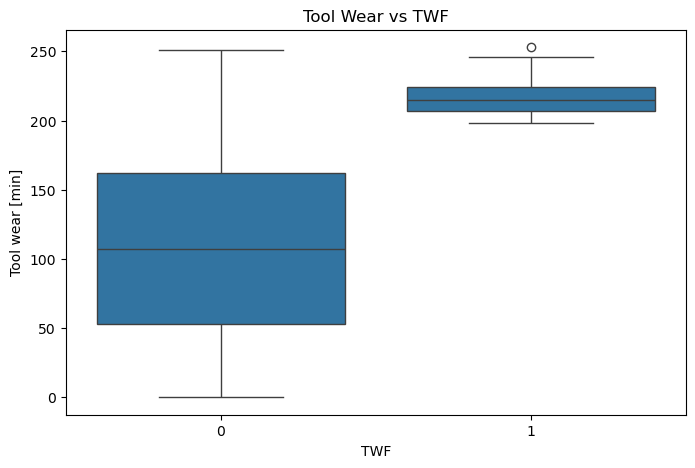

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='TWF',
    y='Tool wear [min]',
    data=df
)

plt.title('Tool Wear vs TWF')

plt.show()

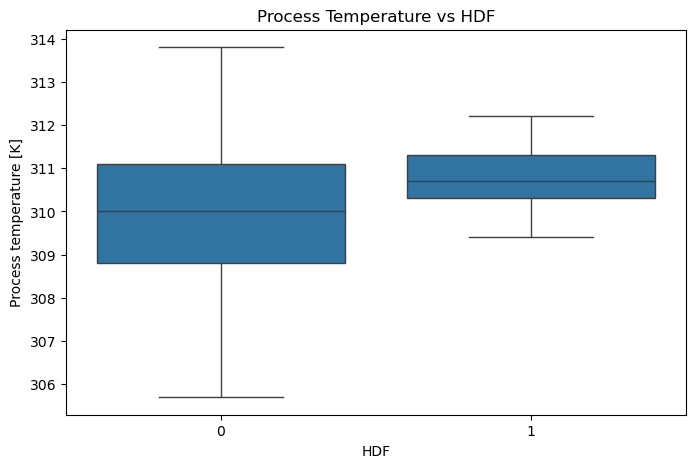

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='HDF',
    y='Process temperature [K]',
    data=df
)

plt.title('Process Temperature vs HDF')

plt.show()

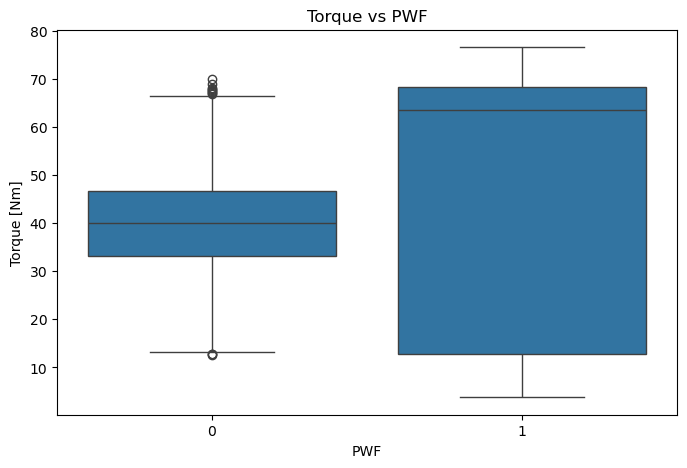

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x='PWF',y='Torque [Nm]',data=df)
plt.title('Torque vs PWF')
plt.show()

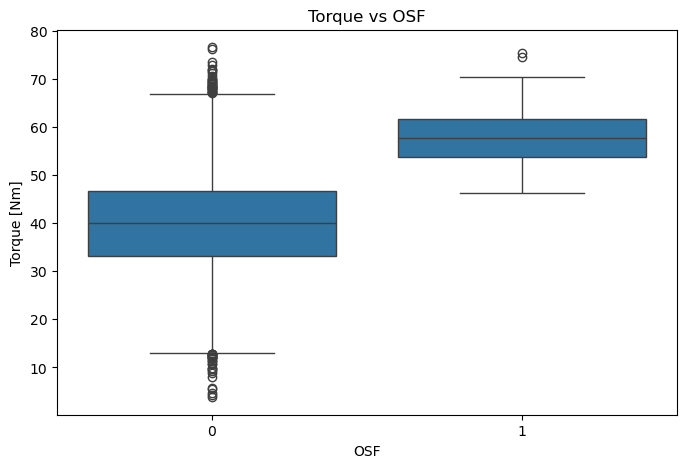

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='OSF',
    y='Torque [Nm]',
    data=df
)

plt.title('Torque vs OSF')

plt.show()

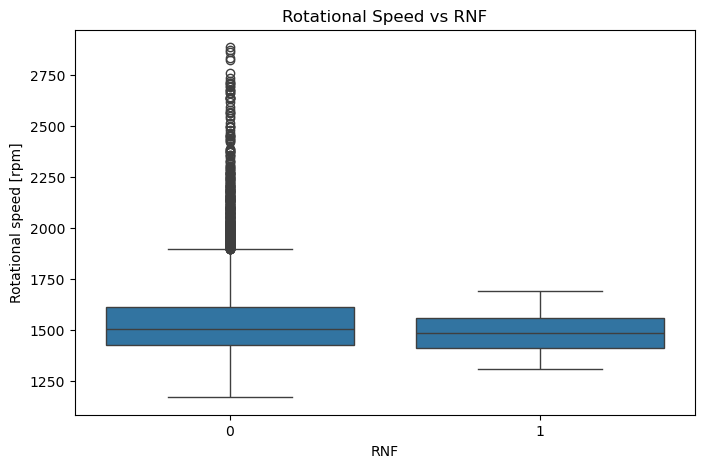

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='RNF',
    y='Rotational speed [rpm]',
    data=df
)

plt.title('Rotational Speed vs RNF')

plt.show()

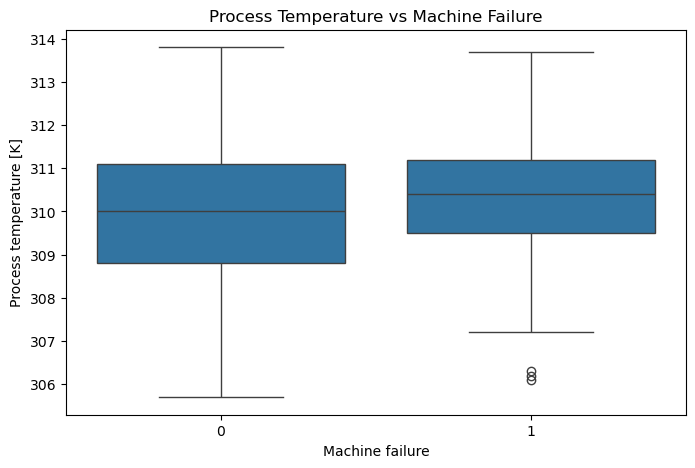

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='Process temperature [K]',
    data=df
)

plt.title('Process Temperature vs Machine Failure')

plt.show()

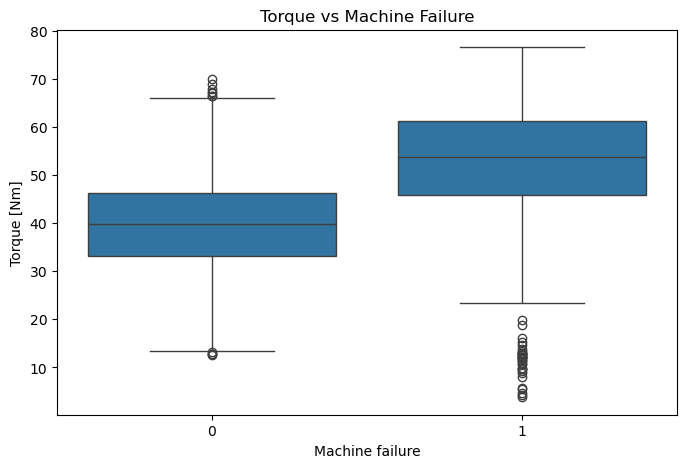

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='Torque [Nm]',
    data=df
)

plt.title('Torque vs Machine Failure')

plt.show()

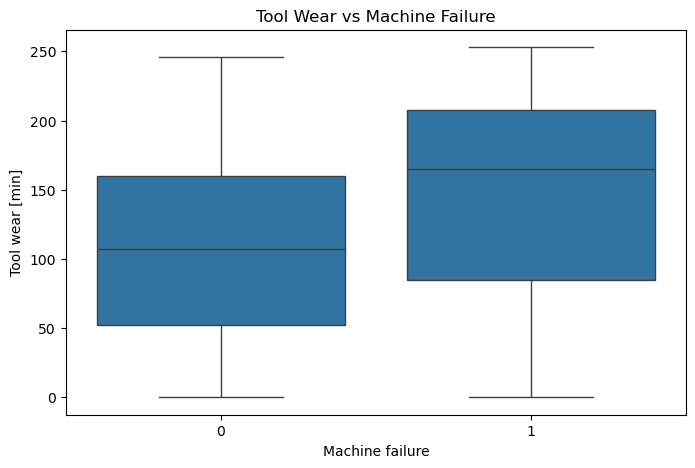

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='Tool wear [min]',
    data=df
)

plt.title('Tool Wear vs Machine Failure')

plt.show()

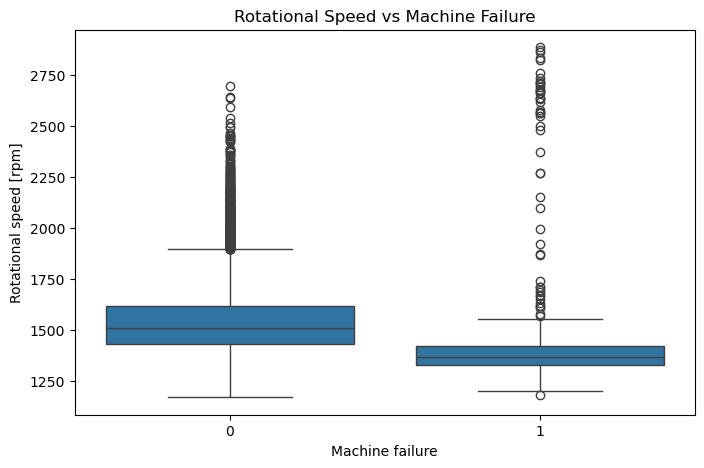

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='Rotational speed [rpm]',
    data=df
)

plt.title('Rotational Speed vs Machine Failure')

plt.show()

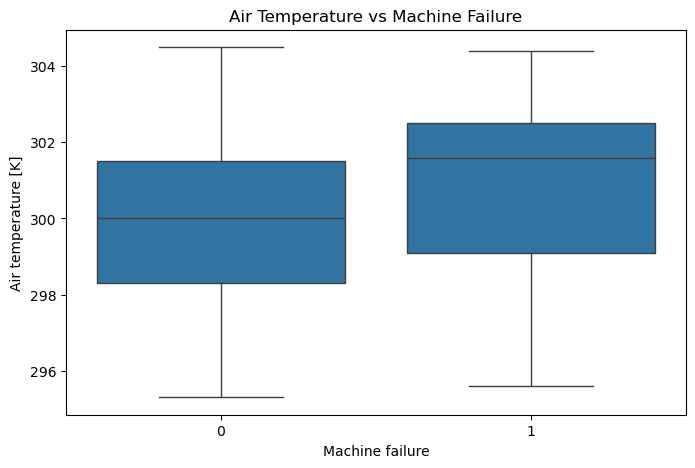

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Machine failure',
    y='Air temperature [K]',
    data=df
)

plt.title('Air Temperature vs Machine Failure')

plt.show()

## Phase 3 — Feature Engineering

In [27]:
df['Power'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']

In [28]:
df[['Torque [Nm]', 'Rotational speed [rpm]', 'Power']].head()

,Torque [Nm],Rotational speed [rpm],Power
0,42.8,1551,66382.8
1,46.3,1408,65190.4
2,49.4,1498,74001.2
3,39.5,1433,56603.5
4,40.0,1408,56320.0


In [29]:
df['Temp_diff'] = (
    df['Process temperature [K]'] 
    - df['Air temperature [K]']
)

In [30]:
df[['Process temperature [K]','Air temperature [K]','Temp_diff']].head()

,Process temperature [K],Air temperature [K],Temp_diff
0,308.6,298.1,10.5
1,308.7,298.2,10.5
2,308.5,298.1,10.4
3,308.6,298.2,10.4
4,308.7,298.2,10.5


In [31]:
X = df.drop(['Machine failure', 'Product ID', 'UDI'], axis=1)

In [32]:
y = df['Machine failure']

In [33]:
X = pd.get_dummies(X,columns=['Type'],drop_first=True)

In [34]:
print(X.columns)

Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF', 'Power', 'Temp_diff', 'Type_L', 'Type_M'],
      dtype='object')


## Phase 4 — Model Training

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 14)
(2000, 14)
(8000,)
(2000,)


In [38]:
from sklearn.preprocessing import StandardScaler 

In [39]:
scaler = StandardScaler()

In [40]:
X_train_scaled = scaler.fit_transform(X_train)

In [41]:
X_test_scaled = scaler.transform(X_test)

In [42]:
print(X_train_scaled[:5])

[[ 0.99891359  0.60428162 -0.46060741  0.71830476 -0.84399726 -0.06723349
  -0.10424403 -0.10176517 -0.10176517 -0.04334192  0.85238725 -1.10084184
  -1.23436595  1.53620728]
 [-1.50519408 -1.15325984 -0.77557391  0.63845583  0.38226308 -0.06723349
  -0.10424403 -0.10176517 -0.10176517 23.07234997  0.48036335  1.29965826
  -1.23436595  1.53620728]
 [ 0.49809206  1.07746586 -1.00765448  0.5586069   0.46086951 -0.06723349
  -0.10424403 -0.10176517 -0.10176517 -0.04334192  0.18404108  0.5995124
  -1.23436595  1.53620728]
 [-0.55363316 -0.13929361 -0.70926517  1.62658635 -0.37235867 -0.06723349
  -0.10424403 -0.10176517 -0.10176517 -0.04334192  1.89886071  0.89957491
   0.81013252 -0.65095382]
 [-1.45511192 -1.01806434  1.07001923 -1.12820177 -0.90688241 -0.06723349
  -0.10424403 -0.10176517 -0.10176517 -0.04334192 -1.00168744  1.3996791
   0.81013252 -0.65095382]]


In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)

In [45]:
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
from sklearn.model_selection import cross_val_score

In [47]:
cv_scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

In [48]:
print(cv_scores)

[0.98113208 0.97142857 0.99065421 0.99065421 1.        ]


In [49]:
print(cv_scores.mean())

0.9867738116230445


## Phase 5 — Evaluation & Insights

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

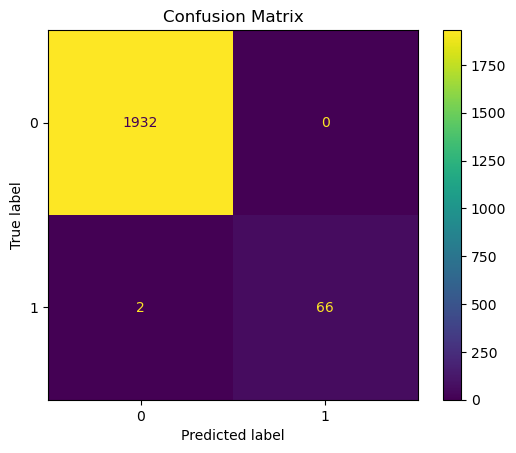

In [51]:
ConfusionMatrixDisplay.from_estimator(rf_model, X_test_scaled, y_test)
plt.title("Confusion Matrix")
plt.show()

In [52]:
from sklearn.metrics import classification_report

In [53]:
y_pred = rf_model.predict(X_test_scaled)

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [55]:
importance = rf_model.feature_importances_

In [56]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

In [57]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

In [58]:
print(feature_importance)

                    Feature  Importance
6                       HDF    0.217514
8                       OSF    0.202744
7                       PWF    0.138625
10                    Power    0.111673
5                       TWF    0.106141
2    Rotational speed [rpm]    0.064628
3               Torque [Nm]    0.059619
11                Temp_diff    0.039483
4           Tool wear [min]    0.032403
0       Air temperature [K]    0.012843
1   Process temperature [K]    0.010185
12                   Type_L    0.002508
13                   Type_M    0.001277
9                       RNF    0.000356


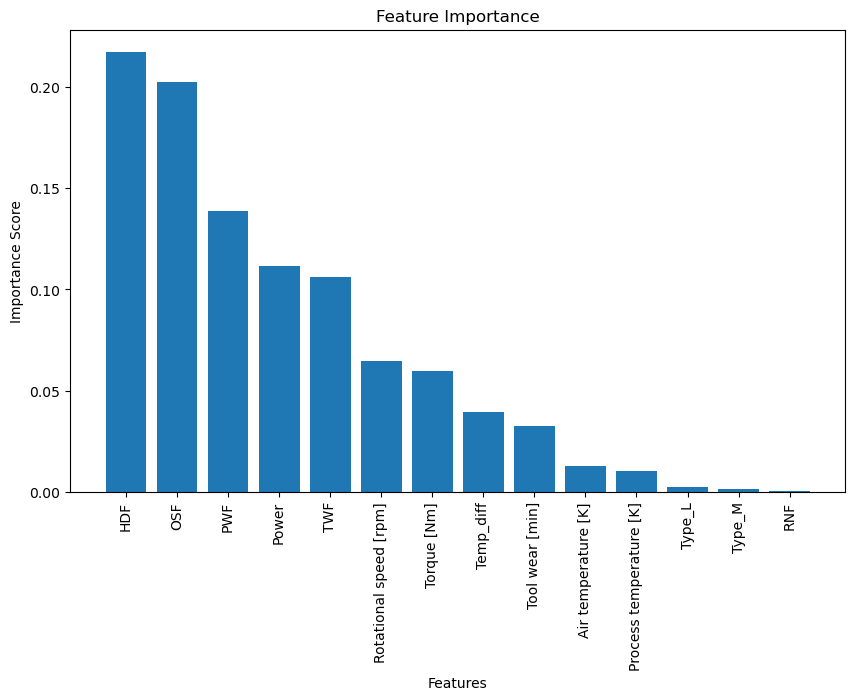

In [59]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()

In [60]:
#pip install xgboost

In [61]:
from xgboost import XGBClassifier

In [62]:
xgb_model = XGBClassifier(
    random_state=42
)

In [63]:
xgb_model.fit(X_train_scaled, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [64]:
xgb_pred = xgb_model.predict(X_test_scaled)

In [65]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



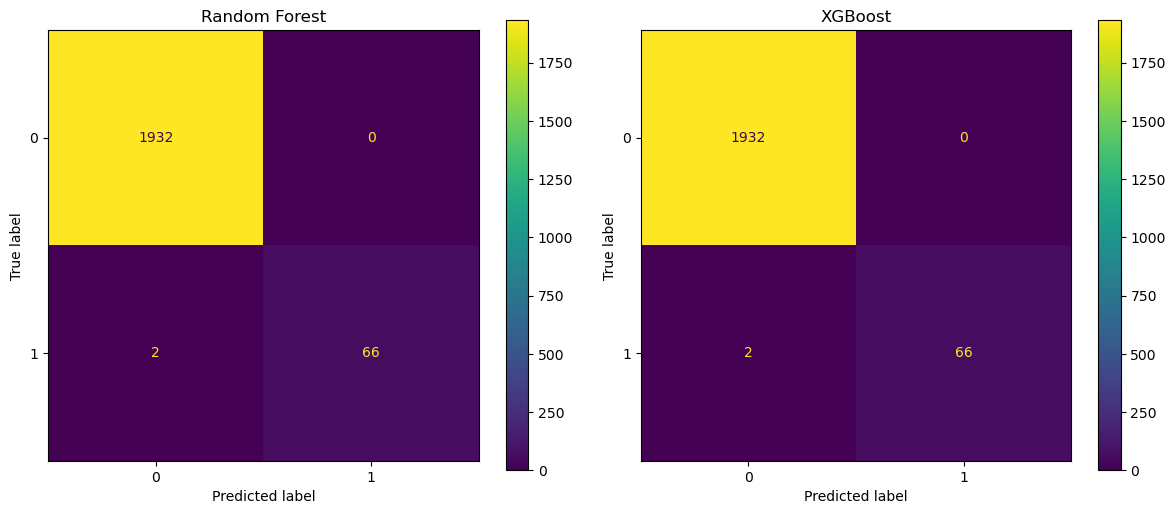

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test_scaled,
    y_test,
    ax=axes[0]  # 0 displays graph to left side
)
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test_scaled,
    y_test,
    ax=axes[1]   
)
axes[1].set_title("XGBoost")

plt.tight_layout()  
plt.show()

# Conclusion

- Random Forest and XGBoost were trained for predictive maintenance classification.
- Both models achieved excellent and identical performance on the dataset.
- Precision reached 1.00, meaning almost no false alarms occurred.
- Recall for machine failures was 0.97, meaning most failures were successfully detected.
- F1-score was 0.99, showing strong balance between precision and recall.
- Overall, both models performed similarly and proved highly effective for predictive maintenance tasks.
- Cross-validation F1 score: 0.987 (Random Forest)
- Top predictive features: HDF, OSF, PWF, Power, TWF
- Limitation: failure type flags (HDF, OSF, PWF) may not be available in real-time deployment — raw sensor features (torque, tool wear) would be the practical predictors in production.